In [1]:
import pandas as pd

In [20]:
file_path = r"C:\Users\user\Desktop\S3.Antibacterial_Susceptibility_Testing_Result.csv"   #used raw string

In [21]:
# Checked if the path exists
import os

print(file_path)
print(os.path.exists(file_path))
print(os.path.splitext(file_path))

C:\Users\user\Desktop\S3.Antibacterial_Susceptibility_Testing_Result.csv
True
('C:\\Users\\user\\Desktop\\S3.Antibacterial_Susceptibility_Testing_Result', '.csv')


In [23]:
# Checked some information
with open(file_path, "rb") as f:
    print(f.read(20))

b'\xef\xbb\xbfBacteria Name,Str'


In [27]:
# Reading the file as plain data
df_raw = pd.read_csv(file_path, header=None)

# Extract the header rows based on the observed structure
header_general = df_raw.iloc[0] # Extracted first row ((row index 0)/Contains 'Bacteria Name', 'Strain Number', 'Antibiotic Groups/Antibiotics'

In [28]:
header_groups_level = df_raw.iloc[1] # Extracted second row (row index 1)/Contains the antibiotic classes, e.g., 'Penicillins', 'Cephalosporins'
header_antibiotics_level = df_raw.iloc[2] # Extracted third row (row index 2)/Contains the antibiotic names, e.g., 'Ampicillin (AMP)', 'Cefotaxime (CTX)'
header_measurements_level = df_raw.iloc[3] # Extracted fourth row (row index 3)/Contains the measurements,# e.g., 'Mean', 'SD', 'AST'

In [29]:
# Created a list to store the final flattened column names
final_column_names = []

In [30]:
# Handling the first two columns separately because they are not antibiotic measurements
final_column_names.append(header_general.iloc[0]) # 'Bacteria Name'
final_column_names.append(header_general.iloc[1]) # 'Strain Number'

In [31]:
# Process the remaining columns for antibiotic data
current_group = ''
current_antibiotic = ''

In [32]:
for col_idx in range(2, len(df_raw.columns)): # Start from column index 2 for antibiotic data
    # Update current_group if a new group name is encountered in header_groups_level
    if pd.notna(header_groups_level.iloc[col_idx]):
        current_group = header_groups_level.iloc[col_idx]

    # Update current_antibiotic if a new antibiotic name is encountered in header_antibiotics_level
    if pd.notna(header_antibiotics_level.iloc[col_idx]):
        current_antibiotic = header_antibiotics_level.iloc[col_idx]

    # Get the measurement type for the current column from header_measurements_level
    measurement = header_measurements_level.iloc[col_idx]

    # Clean up and combine parts to form the column name
    group_str = str(current_group).strip()
    antibiotic_str = str(current_antibiotic).strip()
    measurement_str = '' if pd.isna(measurement) else str(measurement).strip()

    # Form the column name, handling potential empty strings and cleaning underscores
    col_name = f"{group_str}_{antibiotic_str}_{measurement_str}"
    col_name = col_name.replace('__', '_').strip('_') # Remove double underscores and leading/trailing underscores
    final_column_names.append(col_name)


In [33]:
# Assign the new column names and slice the data (skipping the 4 header rows)
df = df_raw.iloc[4:].copy() # Use .copy() to avoid SettingWithCopyWarning
df.columns = final_column_names
df = df.reset_index(drop=True)

display(df.head())

,Bacteria Name,Strain Number,Penicillins_Ampicillin (AMP)_Mean,Penicillins_Ampicillin (AMP)_SD,Penicillins_Ampicillin (AMP)_AST,Cephalosporins_Cefotaxime (CTX)_Mean,Cephalosporins_Cefotaxime (CTX)_SD,Cephalosporins_Cefotaxime (CTX)_AST,Cephalosporins_Ceftazidime (CAZ)_Mean,Cephalosporins_Ceftazidime (CAZ)_SD,...,Carbapenems_Meropenem (MEM)_Mean,Carbapenems_Meropenem (MEM)_SD,Carbapenems_Meropenem (MEM)_AST,Carbapenems_Imipenem (IMI)_Mean,Carbapenems_Imipenem (IMI)_SD,Carbapenems_Imipenem (IMI)_AST,Macrolides_Azithromycin (AZM)_Mean,Macrolides_Azithromycin (AZM)_SD,Macrolides_Azithromycin (AZM)_AST,Macrolides_Azithromycin (AZM)
0,Plesiomonas shigelloides,NIB001,21.33333333,1.527525232,S,28.33333333,2.081665999,S,28,2,...,30.66666667,1.154700538,S,27.66666667,1.527525232,S,16.33333333,1.154700538,S,NaN
1,Providencia stuartii,NIB002,18.66666667,0.577350269,S,19.66666667,1.527525232,R,24.33333333,2.081665999,...,27.66666667,1.527525232,S,28,1.732050808,S,12.33333333,1.154700538,R,NaN
2,Cytrobacter warkmanii,NIB003,21.66666667,1.527525232,S,29,0,S,26.33333333,1.154700538,...,31,1,S,25,0,S,12.66666667,0.577350269,R,NaN
3,Escherichia coli,NIB044,0,0,R,0,0,R,13.66666667,0.577350269,...,26.66666667,1.527525232,S,23.33333333,1.154700538,S,0,0,R,NaN
4,Morganella morganii,NIB006,25.33333333,1.154700538,S,28,1.732050808,S,29.33333333,1.527525232,...,28,1,S,27.33333333,1.527525232,S,9.666666667,2.081665999,R,NaN


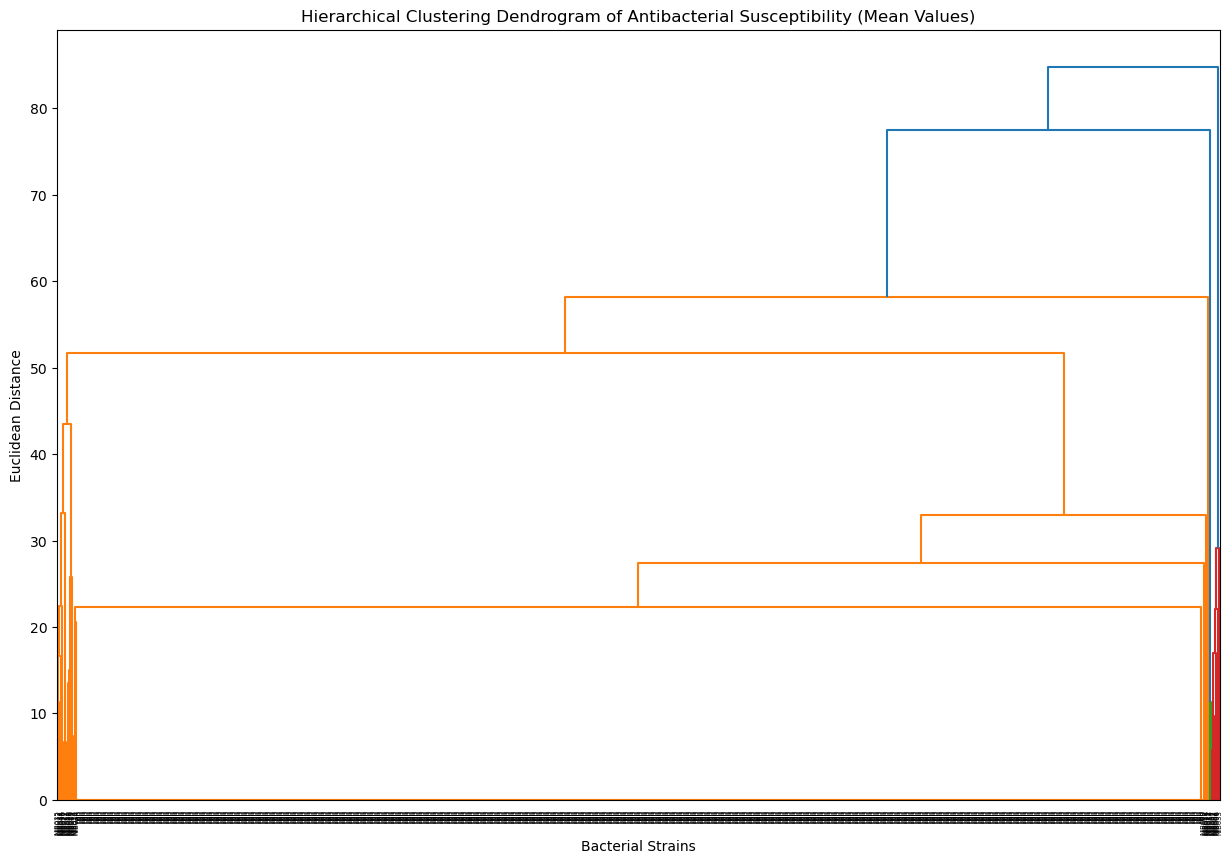

In [39]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import cophenet
import matplotlib.pyplot as plt
import seaborn as sns

# Select only '_Mean' columns for clustering
mean_columns = [col for col in df.columns if col.endswith('_Mean')]

df_mean_cluster = df[mean_columns].copy()

# Convert all selected columns to numeric, coercing errors to NaN
for col in df_mean_cluster.columns:
    df_mean_cluster[col] = pd.to_numeric(df_mean_cluster[col], errors='coerce')

# Handle missing values: Impute with the mean
df_mean_cluster = df_mean_cluster.fillna(df_mean_cluster.mean())

# Standardize the data
scaler = StandardScaler()
df_mean_scaled_cluster = scaler.fit_transform(df_mean_cluster)

# Perform hierarchical clustering
# 'ward' linkage minimizes the variance within each cluster
linked_mean = linkage(df_mean_scaled_cluster, method='ward')

# Plot the dendrogram
plt.figure(figsize=(15, 10))
dendrogram(
    linked_mean,
    orientation='top',
    labels=df['Strain Number'].tolist(), # Use Strain Number for labels as requested
    distance_sort='descending',
    show_leaf_counts=True
)
plt.title('Hierarchical Clustering Dendrogram of Antibacterial Susceptibility (Mean Values)')
plt.xlabel('Bacterial Strains')
plt.ylabel('Euclidean Distance')
plt.show()

In [40]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Select only '_Mean' columns for clustering
mean_columns_kmeans = [col for col in df.columns if col.endswith('_Mean')]

df_kmeans_data = df[mean_columns_kmeans].copy()

# Convert all selected columns to numeric, coercing errors to NaN
for col in df_kmeans_data.columns:
    df_kmeans_data[col] = pd.to_numeric(df_kmeans_data[col], errors='coerce')

# Handle missing values: Impute with the mean
df_kmeans_data = df_kmeans_data.fillna(df_kmeans_data.mean())

# Standardize the data
scaler_kmeans = StandardScaler()
df_kmeans_scaled = scaler_kmeans.fit_transform(df_kmeans_data)

# To visualize the clusters, we'll reduce the dimensionality using PCA
pca_kmeans = PCA(n_components=2)
principal_components_kmeans = pca_kmeans.fit_transform(df_kmeans_scaled)

pca_kmeans_df = pd.DataFrame(data = principal_components_kmeans, columns = ['PC1', 'PC2'])
pca_kmeans_df['Bacteria Name'] = df['Bacteria Name']
pca_kmeans_df['Strain Number'] = df['Strain Number']

print("Data prepared for K-means clustering and PCA for visualization.")
display(pca_kmeans_df.head())

Data prepared for K-means clustering and PCA for visualization.


,PC1,PC2,Bacteria Name,Strain Number
0,23.509919,2.551985,Plesiomonas shigelloides,NIB001
1,20.199728,5.969810,Providencia stuartii,NIB002
2,22.774170,2.424076,Cytrobacter warkmanii,NIB003
3,-12.408234,-1.012183,Escherichia coli,NIB044
4,27.837147,4.399008,Morganella morganii,NIB006


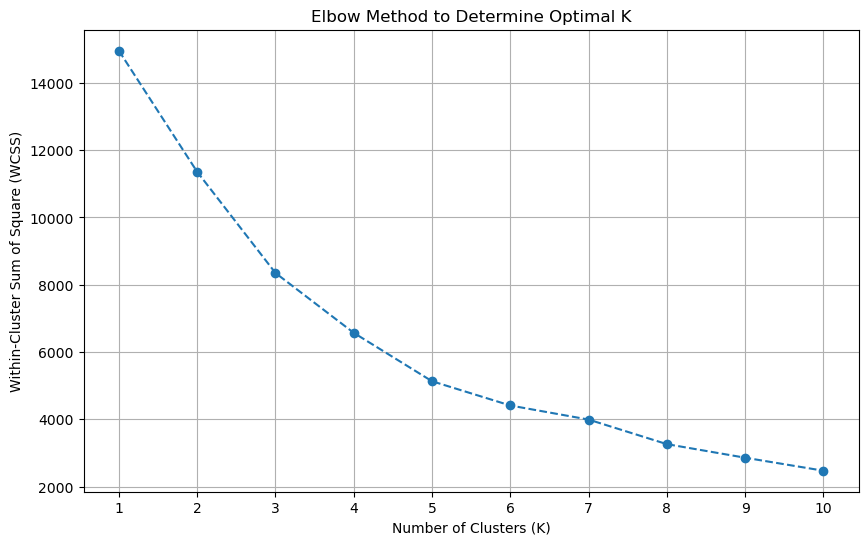

In [41]:
wcss = []
for i in range(1, 11): # Test K from 1 to 10
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_kmeans_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Square (WCSS)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()